In [72]:
import torch
from sklearn import datasets
from torch import nn
import matplotlib.pyplot as plt


Será utilizado o dataset "breast cancer" presente na biblioteca sklearn como exemplo.

In [73]:
breast = datasets.load_breast_cancer()
features = [0, 29]
data = breast.data[:, features]
target = breast.target

print('Data shape ', data.shape, 'and target shape ', target.shape)
print('Breast feature names ', breast.feature_names, 'and breast taarget names ',breast.target_names)

Data shape  (569, 2) and target shape  (569,)
Breast feature names  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension'] and breast taarget names  ['malignant' 'benign']


Seleciona-se 2 atributos para realizar a visualização dos dadosp

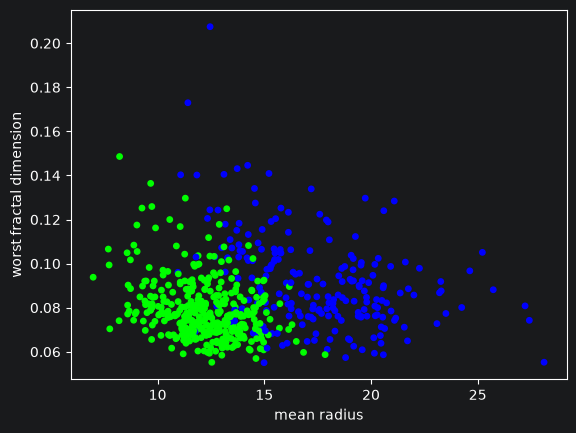

In [74]:
plt.scatter(data[:, 0], data[:, 1], c=target, s=15, cmap=plt.cm.brg )
plt.xlabel(breast.feature_names[features[0]])
plt.ylabel(breast.feature_names[features[1]])

plt.show()


A estrutura da MLP será instanciada contendo uma camada escondida e uma camada de saída.

Padronizam-se os dados para que a convergência não seja prejudicada

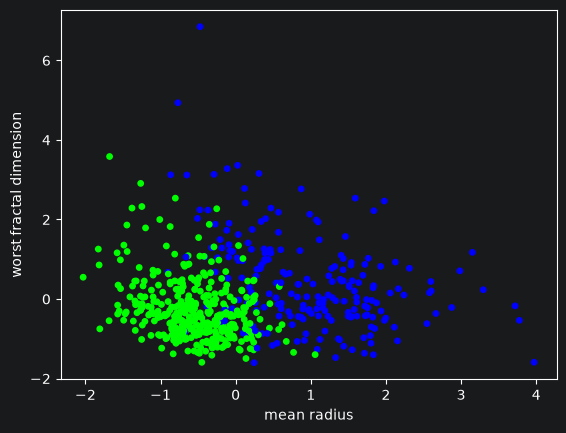

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data = scaler.fit_transform(data)

plt.scatter(data[:, 0], data[:, 1], c=target, s=15, cmap=plt.cm.brg )
plt.xlabel(breast.feature_names[features[0]])
plt.ylabel(breast.feature_names[features[1]])

plt.show()

In [76]:
class BreastClassifier(nn.Module):

    def __init__(self, input_size, hidden_size, out_size):
        super(BreastClassifier, self).__init__()

        # Define-se a arquitetura da MLP
        self.hidden = nn. Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.out = nn.Linear(hidden_size, out_size)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):

        # Gera-se uma saída a partir dos dados x
        feature = self.relu(self.hidden(x))
        output = self.softmax(self.out(feature))

        return output

input_size = data.shape[1]
hidden_size = 32
out_size = len(breast.target_names)

net = BreastClassifier(input_size, hidden_size, out_size)


A função abaixo permite a visualização da fronteira de decisão da rede neural

In [77]:
import numpy as np

def plot_boundary(x, y, model):
  x_min, x_max = x[:, 0].min()-0.1, x[:, 0].max()+0.1
  y_min, y_max = x[:, 1].min()-0.1, x[:, 1].max()+0.1

  spacing = min(x_max - x_min, y_max - y_min) / 100

  XX, YY = np.meshgrid(np.arange(x_min, x_max, spacing),
                       np.arange(y_min, y_max, spacing))

  data = np.hstack((XX.ravel().reshape(-1,1),
                    YY.ravel().reshape(-1,1)))

  # For binary problems
  # db_prob = model(Variable(torch.Tensor(data)).cuda() )
  # clf = np.where(db_prob.cpu().data < 0.5,0,1)

  # For multi-class problems
  db_prob = model(torch.Tensor(data))
  clf = np.argmax(db_prob.cpu().data.numpy(), axis=-1)

  Z = clf.reshape(XX.shape)

  plt.contourf(XX, YY, Z, cmap=plt.cm.brg, alpha=0.5)
  plt.scatter(x[:,0], x[:,1], c=y, edgecolors='k', s=25, cmap=plt.cm.brg)


In [78]:
# plot_boundary(data, target, net)

Nesta etapa é preciso escolher uma função de perda, responsável por apontar a convergência do modelo. A CrossEntropy será testada nesse caso. E também é preciso escolher um otimizador, nesse caso será utilizado o gradiente estocástico.

In [79]:
from torch import optim

# Função de perda
criterion = nn.CrossEntropyLoss()

# Otimização
optimzer = optim.SGD(net.parameters(), lr=1e-3)


Os dados devem ser transformados em tensores para serem introduzidos na MLP

In [80]:
xtns = torch.from_numpy(data).float()
ytns = torch.from_numpy(target)

print('X shape ', xtns.shape, ' and y shape ', ytns.shape)

X shape  torch.Size([569, 2])  and y shape  torch.Size([569])


In [81]:
# pred = net(xtns)

Conferir se a saída da rede e os rótulos de classificação tem a mesma dimensão

In [82]:
# print(pred.shape, ytns.shape)
# print(pred[3].data, ytns[3].data)

Aplica-se a função de perda

In [83]:
# loss = criterion(pred, ytns)
# print(loss)

É utilizado um laço for para realizar o treinamento da rede, e neste caso serão realizadas 100 iterações, incluindo todas as etapas mostradas separadamente acima, alimentação dos dados na rede, cálculo da função de perda, atualização dos pesos dos neurônios e aplicação da função de otimização

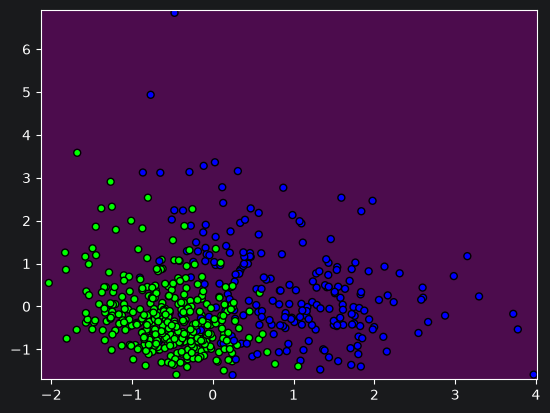

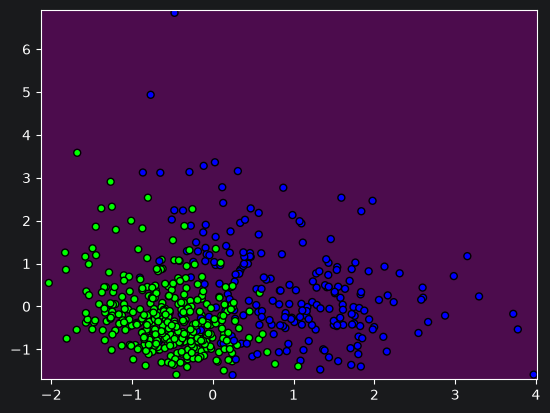

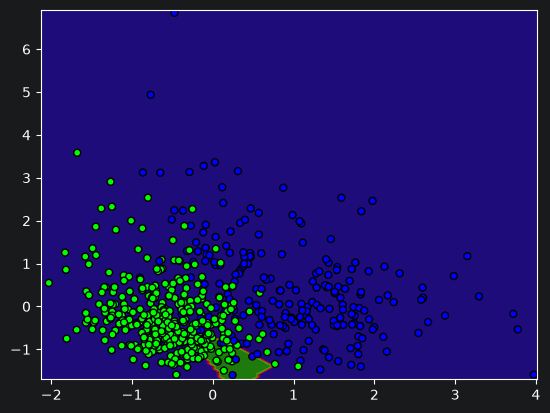

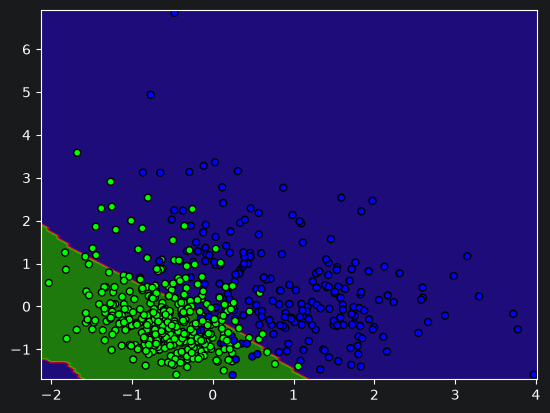

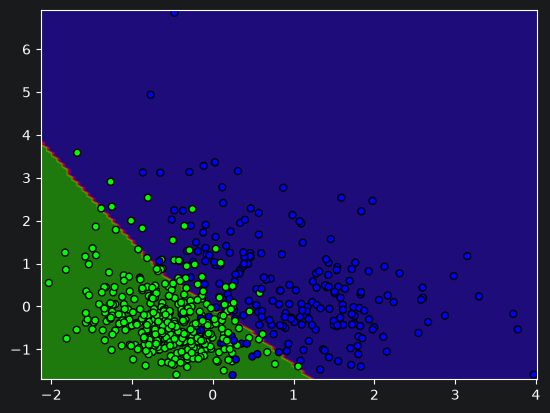

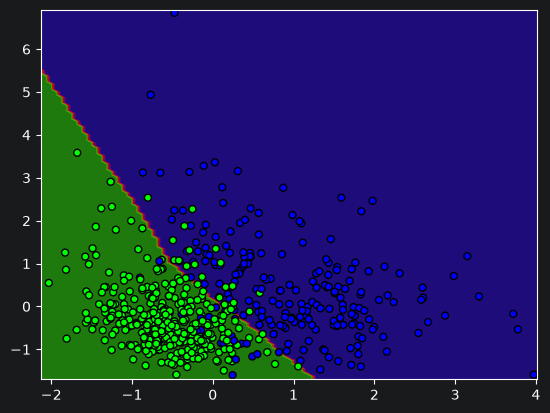

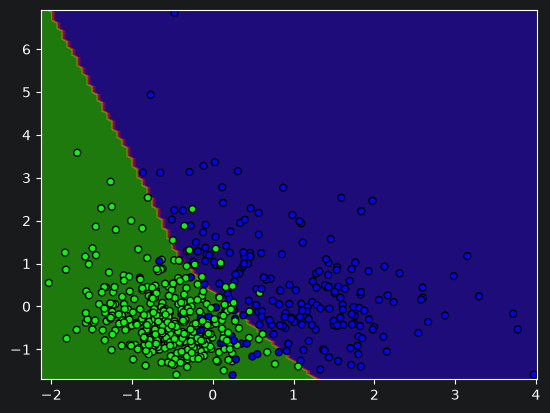

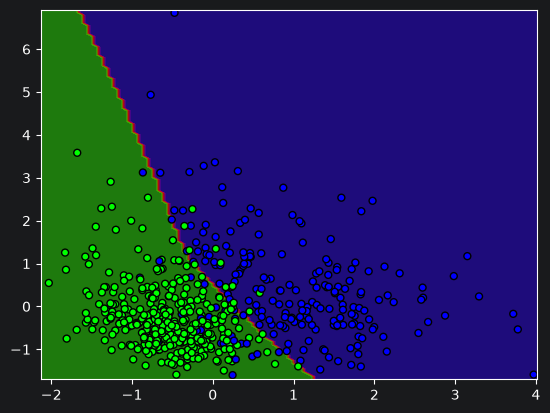

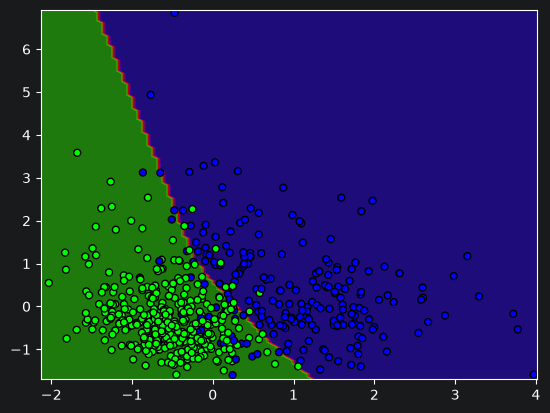

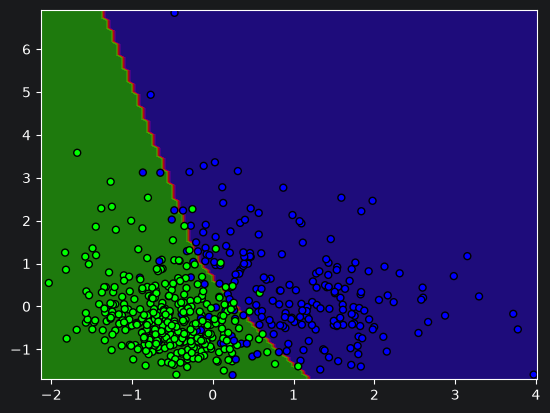

In [84]:
for i in range(100):

    # Forward
    pred = net(xtns) # alimenta a rede com os dados de entrada
    loss = criterion(pred, ytns) # a função de perda é calculada entre a predição da rede e os dados empíricos do banco de dados

    # Backward: os pesos das sinapses são atualizadas de trás para frente
    loss.backward()
    optimzer.step()

    if i % 10 == 0:
        plt.figure()
        plot_boundary(data, target, net) # a cada 10 iterações plota-se um gráfico para a visualização da fronteira de decisão.
